## Calculating the critical threshold

In [1]:
import aliases # important this goes first to configure PATH

In [132]:
import os
import pickle
import math
from pathlib import Path

import pandas as pd
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import numpy as np
import math

from everest.window import Canvas, DataChannel as Channel
from analysis import cylindrical

In [245]:
with (Path(aliases.storagedir) / 'simple_critical_all.data').open(mode='rb') as file:
    loaded = pickle.load(file)
def sortfn(params):
    out = []
    params = dict(params)
    for key in sorted(params):
        val = params[key]
        out.append(key)
        out.append(-1e12 if val is None else val)
    return tuple(out)
loaded = tuple((key, loaded[key]) for key in sorted(loaded, key=sortfn))

In [246]:
loaded[:10]

(((('H', 0.0),
   ('aspect', 0.5),
   ('etaDelta', None),
   ('f', 1.0),
   ('flux', None)),
  (3373.661239584758,
   3615.800588174239,
   4153.46418763306,
   5113.5142306326225,
   4633.489209132841,
   4393.47669838295,
   4513.482953757895,
   4453.479826070423,
   4423.478262226687,
   4408.4774803048185,
   4415.977871265753,
   4412.227675785285,
   4414.102773525519,
   4413.165224655402,
   4413.633999090461,
   4413.399611872932,
   4413.516805481697,
   4413.575402286078,
   4413.546103883888)),
 ((('H', 0.0),
   ('aspect', 0.5358867312681466),
   ('etaDelta', None),
   ('f', 1.0),
   ('flux', None)),
  (2666.292785859414,
   2857.6618512360833,
   3282.591467652671,
   4041.3441466942754,
   3661.9678071734734,
   3472.279637413072,
   3377.4355525328715,
   3330.013510092771,
   3353.7245313128215,
   3365.5800419228462,
   3371.5077972278586,
   3374.471674880365,
   3372.9897360541117,
   3373.7307054672383,
   3373.360220760675,
   3373.5454631139564,
   3373.638084290

In [239]:
sorted((None, 1.), key=sortfn)

[None, 1.0]

In [205]:
def make_frames():
    with (Path(aliases.storagedir) / 'simple_critical_all.data').open(mode='rb') as file:
        data = pickle.load(file)
    keys = tuple(sorted(('f', 'aspect', 'H', 'flux', 'etaDelta')))
    data = pd.DataFrame([
        [*(val for _, val in params), results[-1]] for params, results in data.items()],
        columns=(*keys, 'alpha'),
        )
    data = data.loc[data['f'] >= 0.3]
    data['f'] = data['f'].replace(1., 0.999)
    # data.loc[data['f'] == 1.] = 0.999
    iso = data.loc[data['etaDelta'].isna()]
    arr = data.loc[~data['etaDelta'].isna()]
    mixed = data.loc[data['flux'].isna()]
    internal = data.loc[~data['flux'].isna()]
    for left in (iso, arr):
        for right in (mixed, internal):
            frm = pd.merge(left, right, 'inner').dropna(axis=1)
            yield (
                frm.set_index(sorted(set.intersection(*map(set, (frm, keys)))))
                ['alpha']
                .sort_index()
                )

isomixed, arrmixed, isointernal, arrinternal = make_frames()

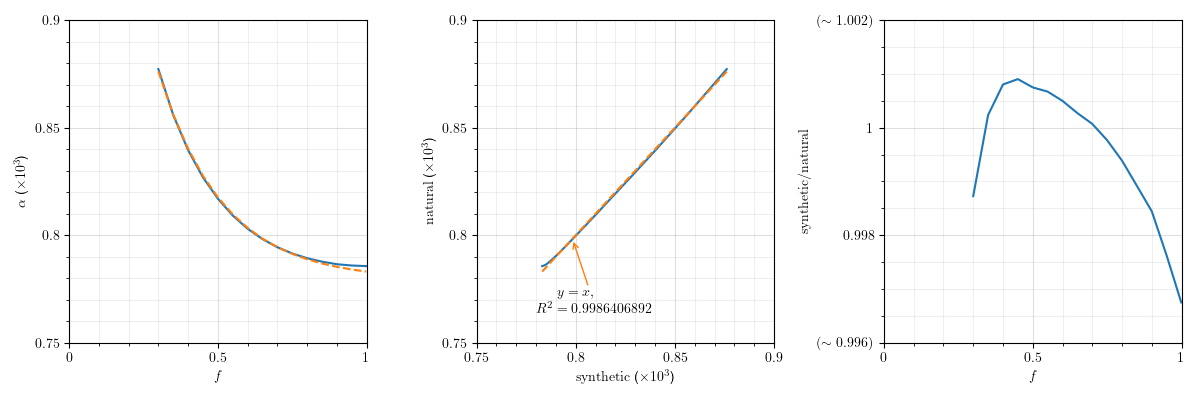

In [211]:
slc = isomixed.loc[0, 1]

canvas = Canvas(size=(12, 4), shape=(1, 3))

def model(x, /, a, b, c):
    return a * b**(x - c) + 8*math.pi**4
(*params,), error = curve_fit(model, slc.index, slc.values)
params = dict(zip('abc', (map(float, params))))
synthetic = model(slc.index, **params)
natural = slc.values
linscore = r2_score(synthetic, natural)

synth_colour = '#ff7f0e'

ax1 = canvas.make_ax((0, 0))

xchan = Channel(
    slc.index, label=r"$f$",
    lims=(None, 1.), capped=(None, True),
    )
ax1.line(
    xchan,
    Channel(
        natural, label=r"$\alpha$",
        ),
    )
ax1.line(
    xchan,
    Channel(
        synthetic,
        ),
    color=synth_colour,
    linestyle='--',
    )

ax2 = canvas.make_ax((0, 1))

ax2.line(
    Channel(synthetic, label=r"$\mathrm{synthetic}$"),
    Channel(natural, label=r"$\mathrm{natural}$"),
    )

ax2.line(
    vals := np.linspace(np.min(synthetic), np.max(synthetic), 10), vals,
    color = synth_colour, linestyle = '--',
    )
ax2.annotate(
    *(map(np.median, (synthetic, natural))),
    label = f"${r'y=x, \\ R^2 =' + str(round(linscore, 10))}$",
    points = (15, -45),
    arrowprops = dict(arrowstyle = "->", color = synth_colour),
    )

ax3 = canvas.make_ax((0, 2))

ax3.line(
    xchan,
    Channel(
        synthetic / natural, label=r"$\mathrm{synthetic} / \mathrm{natural}$",
        )
    )


canvas

In [194]:
isomixed

H     aspect    f   
0.0   1.000000  0.30    877.247530
                0.35    855.894173
                0.40    839.529794
                0.45    826.853705
                0.50    816.991470
                           ...    
10.0  1.866066  0.90    688.209083
      2.000000  0.60    711.422567
                0.70    716.453185
                0.80    721.489970
                0.90    726.269545
Name: alpha, Length: 779, dtype: float64

In [213]:
slc

aspect
0.500000    4413.546104
0.535887    3373.661240
0.574349    2666.292786
0.615572    2167.295211
0.659754    1799.387691
0.707107    1523.412171
0.757858    1311.889865
0.812252    1149.142845
0.870551    1023.078329
0.933033     925.462139
1.000000     785.620241
1.071773     738.011241
1.148698     703.336392
1.231144     679.864766
1.319508     666.350716
1.414214     661.906959
1.515717     665.992214
1.624505     678.320538
1.741101     734.539710
1.866066     763.673684
2.000000     802.219714
2.143547     850.555224
2.297397     909.717146
2.462289     980.682923
2.639016    1064.777948
2.828427    1163.562247
3.031433    1278.890707
3.249010    1413.064424
3.482202    1568.407385
3.732132    1748.120217
4.000000    1955.668947
Name: alpha, dtype: float64

In [226]:
with open(
        os.path.join(
            aliases.storagedir, 'livestation', 'alphacrit_aspect_f.pkl'
            ), mode='rb'
        ) as file:
    aspects = pickle.load(file)
aspects = pd.DataFrame(
    [(key, vals[1.][-1]) for key, vals in aspects.items()],
    columns=['aspect', 'alpha'],
    ).set_index('aspect').sort_index()['alpha']

In [227]:
aspects

aspect
1.000000    785.620241
1.071773    738.011241
1.148698    703.336392
1.231144    679.864766
1.319508    666.350716
1.414214    661.906959
1.515717    665.992214
1.624505    678.320538
Name: alpha, dtype: float64

In [ ]:
# with open(
#         os.path.join(
#             aliases.storagedir, 'livestation', 'alphacrit_f_fine.pkl'
#             ), mode='rb'
#         ) as file:
#     olddatas = pickle.load(file)

# with open(
#         os.path.join(
#             aliases.storagedir, 'livestation', 'alphacrit_aspect_f.pkl'
#             ), mode='rb'
#         ) as file:
#     alldatas = pickle.load(file)
# newdatas = alldatas[1.0]

# datas = {**olddatas, **newdatas}

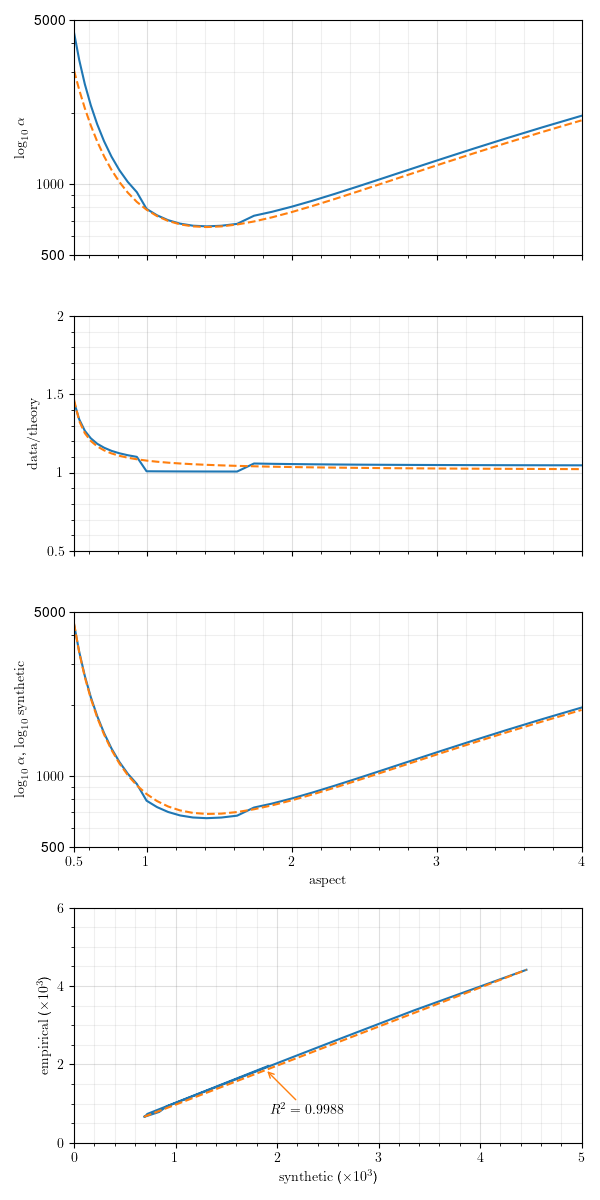

{'a': 0.09100267184029143,
 'b': 2.4004792841280476,
 'c': -0.4163101964000646,
 'd': 1.011269242812055}

In [216]:
slc = isomixed.loc[0, :, 0.999]

crit_func = lambda A: math.pi**4 * (1 + A**2)**3 / A**4
independent = slc.index
empirical = slc.values
theory = tuple(map(crit_func, slc.index))
discrepancy = empirical / theory

canvas = Canvas(size = (6, 12), shape = (4, 1))

ax1 = canvas.ax((0, 0))
ax1.line(
    xchan := Channel(
        independent, label=r"$\mathrm{aspect}$",
        log=False, capped=(True, True),
        ),
    ychan := Channel(empirical, label=r"$\alpha$", log=True),
    )
ax1.line(
    xchan, Channel(theory, log=True),
    linestyle='--',
    )

ax1.props.edges.x.label.visible = False
ax1.props.edges.x.ticks.major.labels = ()
# ax1.props.edges.x.swap()
# ax1.props.edges.x.ticks.major.labels[:] = []

def func(x, /, a, b, c, d):
    return a / (b*(x + c)) + d
(*params,), error = curve_fit(func, slc.index, discrepancy)
params = dict(zip('abcd', (map(float, params))))

correction = func(slc.index, **params)

ax2 = canvas.ax((1, 0))
ax2.line(
    xchan,
    Channel(discrepancy, label=r'$\mathrm{data} / \mathrm{theory}$'),
    )
ax2.line(
    xchan,
    Channel(correction),
    linestyle='--',
    )

ax2.props.edges.x.label.visible = False
ax2.props.edges.x.ticks.major.labels = ()

synthetic = theory * correction

ax3 = canvas.ax((2, 0))
ax3.line(
    xchan,
    ychan,
    )
ax3.line(
    xchan,
    Channel(synthetic, label=r"$\mathrm{synthetic}$", log=True),
    linestyle='--',
    )

ax4 = canvas.ax((3, 0))
ax4.line(
    Channel(synthetic, label=r"$\mathrm{synthetic}$"),
    Channel(empirical, label=r"$\mathrm{empirical}$"),
    )
linscore = r2_score(synthetic, empirical)
ax4.line(
    Channel(np.linspace(min(synthetic), max(synthetic), 100)),
    Channel(np.linspace(min(empirical), max(empirical), 100)),
    linestyle = '--',
    )
ax4.annotate(
    (max(synthetic) - min(synthetic)) / 2,
    (max(empirical) - min(empirical)) / 2,
    label = f"${'R^2 =' + str(round(linscore, 5))}$",
    points = (30, -30),
    arrowprops = dict(arrowstyle = "->", color = '#ff7f0e'),
    )

display(canvas)
display(params)

In [ ]:
round(len(synthetic) / 2)

In [ ]:
len(synthetic)

In [ ]:
synthetic